# Lab - DT for classification of 2 classes

1. Use the **load_breast_cancer** data (remember to split your data into a train and a test set). Try to implement a decision tree classifier (with default settings). How well does it perform (i.e. what is its accuracy in diagnosing whether patients have cancer)?
1. Try different values for **max_depth** (must be an integer), **min_samples_split** (an integer OR a fraction), **min_samples_leaf** (an integer OR a fraction), and **max_features** (an integer, a fraction, or one of `"sqrt"`, `"log2"`).

**See slides for more details!**

### Lab 1

Use the **load_breast_cancer** data (remember to split your data into a train and a test set). Try to implement a decision tree classifier (with default settings). How well does it perform (i.e. what is its accuracy in diagnosing whether patients have cancer)?

In [1]:
import pandas as pd

from sklearn import tree
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# `return_X_y` parameter returns already data splitted
cancer_data = load_breast_cancer(as_frame = True)

df = cancer_data.frame.dropna()

# Labels: 0 = malignat and 1 = benign
y = df["target"]
X = df.drop(["target"], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"X_train {X_train.shape}, X_test {X_test.shape}, y_train {y_train.shape}, y_test {y_test.shape}")

X_train (455, 30), X_test (114, 30), y_train (455,), y_test (114,)


In [6]:
dt_default = tree.DecisionTreeClassifier(random_state = 42).fit(X = X_train, y = y_train)

y_test_hat_default = dt_default.predict(X = X_test)

accuracy_default = accuracy_score(y_true = y_test, y_pred = y_test_hat_default)
print(f'DT with default settings achieved {round(accuracy_default * 100, 1)}% accuracy.')

DT with default settings achieved 94.7% accuracy.


In [7]:
print(f'Depth: {dt_default.get_depth()}')
print(f'Number of leaves: {dt_default.get_n_leaves()}')

Depth: 7
Number of leaves: 16


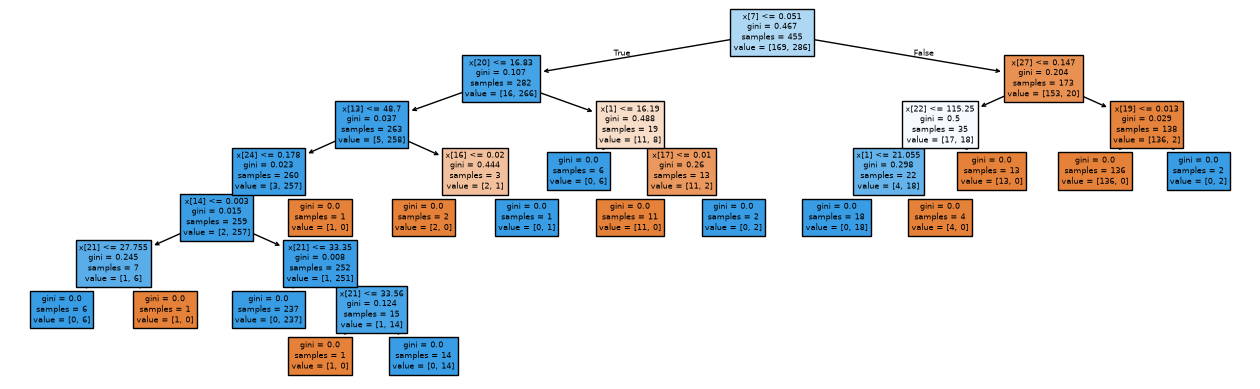

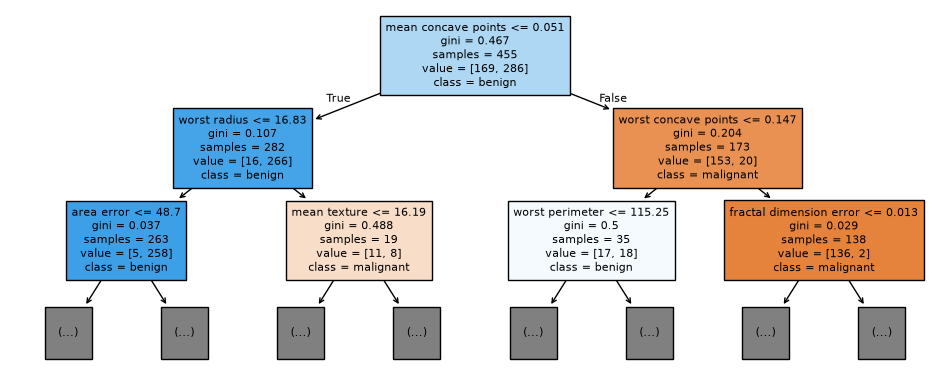

In [8]:
fig = plt.figure(figsize = plt.figaspect(0.3))
ax = fig.add_subplot(1, 1, 1)

tree.plot_tree(dt_default, filled = True)
plt.show()

fig = plt.figure(figsize = plt.figaspect(0.4))
ax = fig.add_subplot(1, 1, 1)

tree.plot_tree(dt_default, filled = True, max_depth = 2, fontsize = 8, feature_names = list(cancer_data.feature_names), class_names = list(cancer_data.target_names))
plt.show()

**Hint**: accuracy score hides which mistakes we did (False Positive and False Negative), and for a diagnosis purpose these two kinds of error are not equally bad. Usually, for a better visualization, we use a confusion matrix looking at (TP, FP, FN, TN).

In [12]:
from sklearn.metrics import confusion_matrix

df_result = pd.DataFrame(confusion_matrix(y_test, y_test_hat_default), columns = ["malignant", "benign"])
display(df_result)

,malignant,benign
0,40,3
1,3,68


The confusion matrix is structured as follows: 
- (0, 0) $\rightarrow$ True Positive, observations correctly classified.
- (0, 1) $\rightarrow$ False Negative, observations badly classified.
- (1, 0) $\rightarrow$ False Positive, observations correctly classified.
- (1, 1) $\rightarrow$ True Negative, observations badly classified.

By the way, in this context we can't assess the mistakes done in the same way: some of the *malignant observations* were classified as *benign*. Therefore, the best approach is to enforce our model to classify False Negative and False Positive as *malignant observations*. 

### Lab 2

Try different values for **max_depth** (must be an integer), **min_samples_split** (an integer OR a fraction), **min_samples_leaf** (an integer OR a fraction), and **max_features** (an integer, a fraction, or one of `"sqrt"`, `"log2"`).

I suggest going through each setting one at a time, trying a more *restricted* (i.e. smaller) value than the default. The reason is that the default value of each setting is the unrestricted version: **the tree is grown until every leaf is pure**.

Concretely, try low values for **max_depth**, **min_samples_split**, **min_samples_leaf**, and **max_features**, and keep an eye on both the accuracy *and* the depth of the resulting tree. Note that `"auto"` used to be an allowed value for **max_features** but has been removed from scikit-learn; use `"sqrt"` instead.

In [ ]:
max_depth = 5

dt_low_max_depth = tree.DecisionTreeClassifier(max_depth = max_depth, random_state = 42).fit(X = X_train, y = y_train)

y_test_hat_low_max_depth = dt_low_max_depth.predict(X = X_test)

accuracy_low_max_depth = accuracy_score(y_true = y_test, y_pred = y_test_hat_low_max_depth)
print(f"DT with max_depth = {max_depth} achieved {round(accuracy_low_max_depth * 100, 1)}% accuracy.")

DT with max_depth = 5 achieved 94.7% accuracy.


In [ ]:
min_samples_split = 10

dt_low_min_samples_split = tree.DecisionTreeClassifier(min_samples_split = min_samples_split, random_state = 42).fit(X = X_train, y = y_train)

y_test_hat_low_min_samples_split = dt_low_min_samples_split.predict(X = X_test)

accuracy_low_min_samples_split = accuracy_score(y_true = y_test, y_pred = y_test_hat_low_min_samples_split)
print(f"DT with min_samples_split = {min_samples_split} achieved {round(accuracy_low_min_samples_split * 100, 1)}% accuracy.")

print(f"Depth with min_samples_split = {dt_low_min_samples_split.get_depth()}.")

DT with min_samples_split = 10 achieved 94.7% accuracy.
Depth with min_samples_split = 7.


In [ ]:
min_samples_leaf = 3

dt_low_min_samples_leaf = tree.DecisionTreeClassifier(min_samples_leaf = min_samples_leaf, random_state = 42).fit(X = X_train, y = y_train)

y_test_hat_low_min_samples_leaf = dt_low_min_samples_split.predict(X = X_test)

accuracy_low_min_samples_leaf = accuracy_score(y_true = y_test, y_pred = y_test_hat_low_min_samples_leaf)
print(f"DT with min_samples_leaf = {min_samples_leaf} achieved {round(accuracy_low_min_samples_leaf * 100, 1)}% accuracy.")

print(f"Depth with min_samples_leaf {dt_low_min_samples_leaf.get_depth()}.")

DT with min_samples_leaf=3 achieved 94.7% accuracy.
Depth with min_samples_leaf 7.


In [25]:
max_features = 5

dt_low_max_features = tree.DecisionTreeClassifier(max_features = max_features, random_state = 42).fit(X = X_train, y = y_train)

y_test_hat_low_max_features = dt_low_max_features.predict(X = X_test)

accuracy_low_max_features = accuracy_score(y_true = y_test, y_pred = y_test_hat_low_max_features)
print(f"DT with max_features = {max_features} achieved {round(accuracy_low_max_features * 100, 1)}% accuracy.")

print(f"Depth with max_features {dt_low_max_features.get_depth()}.")

DT with max_features = 5 achieved 91.2% accuracy.
Depth with max_features 8.
